In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# k-armed Bandit Problem

In [36]:
class Bandit:
    def __init__(self, policy, bandit_args):
        self.n_arms = bandit_args.get('n_arms', 10)
        self._q_true_var = bandit_args.get('q_true_var', 1)
        self.reward_var = bandit_args.get('reward_var', 1)
        self._q_true = None
        self.best_action_idx = None
        self.q_estimate = None
        self.action_count = None
        self.policy = policy
        self._generate_true_action_values()

    def _generate_true_action_values(self):
        self._q_true = np.random.normal(0, self._q_true_var, self.n_arms)  # True action values
        self.q_estimate = np.zeros(self.n_arms)  # Reset estimates
        self.action_count = np.zeros(self.n_arms)  # Reset action counts
        self.best_action_idx = np.argmax(self._q_true)  # Index of the best action
    
    def _reward(self, action):
        return np.random.normal(self._q_true[action], self.reward_var)  # Reward with noise
    
    def _take_action(self, action):
        reward = self._reward(action)
        self.action_count[action] += 1
        # Update estimate using incremental formula
        self.q_estimate[action] += (reward - self.q_estimate[action]) / self.action_count[action]
        return reward
    
    def _get_action(self):
        return self.policy(self.q_estimate)
    
    def run(self, n_steps):
        rewards = np.zeros(n_steps)
        best_action_count = np.zeros(n_steps)
        for step in range(n_steps):
            action = self._get_action()
            rewards[step] = self._take_action(action)
            if action == self.best_action_idx:
                best_action_count[step] = 1
        best_action_perct = np.cumsum(best_action_count) / (np.arange(n_steps) + 1)  # Cumulative average of optimal action count
        
        return {
            'rewards': rewards,
            'best_action_percentage': best_action_perct
        }

In [29]:
def greedy_policy(q_estimate):
    return np.argmax(q_estimate)

def epsilon_greedy_policy(q_estimate, epsilon=0.1):
    if np.random.rand() < epsilon:
        return np.random.randint(len(q_estimate))  # Explore
    else:
        return np.argmax(q_estimate)  # Exploit

In [49]:
bandit_params = {
    'n_arms': 10,
    'q_true_var': 1,
    'reward_var': 1
}

In [50]:
n_steps = 1000
n_iterations = 2000

rewards_greedy = pd.DataFrame(np.zeros((n_iterations, n_steps)))
rewards_epsilon_01 = pd.DataFrame(np.zeros((n_iterations, n_steps)))
rewards_epsilon_001 = pd.DataFrame(np.zeros((n_iterations, n_steps)))

optimal_action_percentages_greedy = pd.DataFrame(np.zeros((n_iterations, n_steps)))
optimal_action_percentages_epsilon_01 = pd.DataFrame(np.zeros((n_iterations, n_steps)))
optimal_action_percentages_epsilon_001 = pd.DataFrame(np.zeros((n_iterations, n_steps)))

for i in range(n_iterations):
    bandit_greedy = Bandit(greedy_policy, bandit_args=bandit_params)
    bandit_epsilon_01 = Bandit(lambda q: epsilon_greedy_policy(q, epsilon=0.1), bandit_args=bandit_params)
    bandit_epsilon_001 = Bandit(lambda q: epsilon_greedy_policy(q, epsilon=0.01), bandit_args=bandit_params)

    tmp = bandit_greedy.run(n_steps)
    rewards_greedy.iloc[i] = tmp['rewards']
    optimal_action_percentages_greedy.iloc[i] = tmp['best_action_percentage']

    tmp = bandit_epsilon_01.run(n_steps)
    rewards_epsilon_01.iloc[i] = tmp['rewards']
    optimal_action_percentages_epsilon_01.iloc[i] = tmp['best_action_percentage']
    
    tmp = bandit_epsilon_001.run(n_steps)
    rewards_epsilon_001.iloc[i] = tmp['rewards']
    optimal_action_percentages_epsilon_001.iloc[i] = tmp['best_action_percentage']

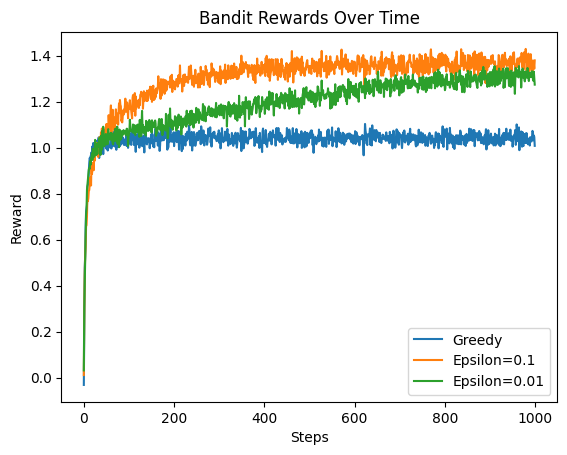

In [51]:
plt.plot(rewards_greedy.mean(), label='Greedy')
plt.plot(rewards_epsilon_01.mean(), label='Epsilon=0.1')
plt.plot(rewards_epsilon_001.mean(), label='Epsilon=0.01')
plt.xlabel('Steps')
plt.ylabel('Reward')
plt.title('Bandit Rewards Over Time')
plt.legend()
plt.show()

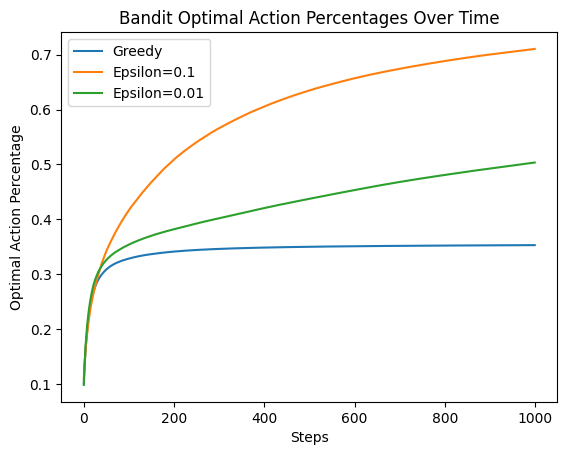

In [52]:
plt.plot(optimal_action_percentages_greedy.mean(), label='Greedy')
plt.plot(optimal_action_percentages_epsilon_01.mean(), label='Epsilon=0.1')
plt.plot(optimal_action_percentages_epsilon_001.mean(), label='Epsilon=0.01')
plt.xlabel('Steps')
plt.ylabel('Optimal Action Percentage')
plt.title('Bandit Optimal Action Percentages Over Time')
plt.legend()
plt.show()